In [135]:
suppressPackageStartupMessages(library(tidyverse))
source("../scripts/00_R_presets.R")

# Figure 1: Assembly QC

Subplots:
- A) T2T overview
- B) QC Beesplot
- C) ReadQC
- D) Chromosome Plot

In [136]:
# Subfigure sizes 182mm = 7,16 inches
sizes <- c(
    "A" = c(6,4),         # T2T Grid
    "B" = c(7,1.5),
    "C" = c(3,2),
    "D" = c(7.16,3)
)

## A: T2T overview


In [137]:
# read data
dt_t2t <- read.table("../../doc/tables/for_plots/T2T_contigs.all.seqinfo.txt", header = TRUE, sep = "\t", stringsAsFactors = FALSE) %>%
    mutate(
        haplotype = case_when(
        grepl("haplotype1", contig) ~ "Hap 1",
        grepl("haplotype2", contig) ~ "Hap 2",
        TRUE ~ "Unknown"
        ),
        # Create sample_haplotype combination for x-axis
        sample_hap = paste(sample, haplotype, sep = "_"),
        # Clean up chromosome names (remove 'chr' prefix for sorting)
        chr_num = gsub("chr", "", chromosome),
        # Convert chromosome to factor with proper ordering
        chr_factor = factor(chromosome, levels = c(
        paste0("chr", 1:22), "chrX", "chrY"
        ))
)

head(dt_t2t)
print(unique(dt_t2t$sample))

,sample,contig,chromosome,contig_length,gap_length,ref_length,motif_length,n_gaps,total_gap_length_bed,mean_gap_size,max_gap_size,min_gap_size,gap_density,haplotype,sample_hap,chr_num,chr_factor
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<fct>
1,T2T00,haplotype1-0000001,chr1,245398328,115000,248387328,245398328,3,115000,38333.3,100000,7500,0.01,Hap 1,T2T00_Hap 1,1,chr1
2,T2T00,haplotype2-0000045,chr1,245133717,22500,248387328,245133717,3,22500,7500.0,7500,7500,0.01,Hap 2,T2T00_Hap 2,1,chr1
3,T2T00,haplotype1-0000004,chr10,136566791,35859,134758134,136566791,1,35859,35859.0,35859,35859,0.01,Hap 1,T2T00_Hap 1,10,chr10
4,T2T00,haplotype2-0000048,chr10,136628182,15000,134758134,136628182,2,15000,7500.0,7500,7500,0.01,Hap 2,T2T00_Hap 2,10,chr10
5,T2T00,haplotype1-0000019,chr11,137904311,0,135127769,137904311,0,0,0.0,0,0,0.00,Hap 1,T2T00_Hap 1,11,chr11
6,T2T00,haplotype2-0000066,chr11,136649847,15000,135127769,136649847,2,15000,7500.0,7500,7500,0.01,Hap 2,T2T00_Hap 2,11,chr11


 [1] "T2T00"   "T2T00_1" "T2T00_2" "T2T01"   "T2T02"   "T2T03"   "T2T04"  
 [8] "T2T04_1" "T2T04_2" "T2T05"   "T2T06"   "T2T07"   "T2T08"   "T2T09"  
[15] "T2T10"   "T2T11"   "T2T12"   "T2T13"   "T2T15"   "T2T16"   "T2T17"  
[22] "T2T18"   "T2T19"  


In [145]:
# Create a complete grid of all sample-haplotype combinations and chromosomes
all_samples <- unique(dt_t2t$sample)  # Changed from df to dt_t2t
all_haplotypes <- c("Hap 1", "Hap 2")  # Match the haplotype labels from dt_t2t
all_chromosomes <- levels(dt_t2t$chr_factor)  # Changed from df to dt_t2t

# Create complete combinations
complete_grid <- expand.grid(
    sample = all_samples,
    haplotype = all_haplotypes,
    chromosome = all_chromosomes,
    stringsAsFactors = FALSE
) %>%
mutate(
    sample_hap = paste(sample, haplotype, sep = "_"),
    chr_factor = factor(chromosome, levels = all_chromosomes
)
)

# Merge with actual data - use dt_t2t instead of df
plot_data <- complete_grid %>%
    left_join(dt_t2t, by = c("sample", "haplotype", "chromosome", "sample_hap", "chr_factor")) %>%
    mutate(
        # Create coverage status based on gap information
        coverage_status = case_when(
            is.na(contig) ~ "Multiple contigs",
            n_gaps == 0 ~ "Complete",
            n_gaps == 1 & gap_length <= 50000 ~ "Single Small Gap",
            n_gaps == 1 & gap_length > 50000 ~ "Single Large Gap", 
            n_gaps > 1 & gap_length <= 100000 ~ "Multiple Small Gaps",
            n_gaps > 1 & gap_length > 100000 ~ "Multiple Large Gaps",
            TRUE ~ "Other"
        )
    ) %>%
    mutate(
        coverage_status_simple = case_when(
            coverage_status == "Complete" ~ "Complete T2T",
            coverage_status %in% c("Single Small Gap", "Single Large Gap", "Multiple Small Gaps", "Multiple Large Gaps") ~ "Near T2T",
            TRUE ~ "Multiple contigs"
        )
    )

head(plot_data)

,sample,haplotype,chromosome,sample_hap,chr_factor,contig,contig_length,gap_length,ref_length,motif_length,n_gaps,total_gap_length_bed,mean_gap_size,max_gap_size,min_gap_size,gap_density,chr_num,coverage_status,coverage_status_simple
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
1,T2T00,Hap 1,chr1,T2T00_Hap 1,chr1,haplotype1-0000001,245398328,115000,248387328,245398328,3,115000,38333.3,100000,7500,0.01,1,Multiple Large Gaps,Near T2T
2,T2T00_1,Hap 1,chr1,T2T00_1_Hap 1,chr1,haplotype1-0000009,248051653,303972,248387328,248051653,13,303972,23382.5,100000,1500,0.05,1,Multiple Large Gaps,Near T2T
3,T2T00_2,Hap 1,chr1,T2T00_2_Hap 1,chr1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,Multiple contigs,Multiple contigs
4,T2T01,Hap 1,chr1,T2T01_Hap 1,chr1,haplotype1-0000012,243437785,15000,248387328,243437785,2,15000,7500.0,7500,7500,0.01,1,Multiple Small Gaps,Near T2T
5,T2T02,Hap 1,chr1,T2T02_Hap 1,chr1,haplotype1-0000028,250387180,15000,248387328,250387180,2,15000,7500.0,7500,7500,0.01,1,Multiple Small Gaps,Near T2T
6,T2T03,Hap 1,chr1,T2T03_Hap 1,chr1,haplotype1-0000015,247552703,0,248387328,247552703,0,0,0.0,0,0,0.00,1,Complete,Complete T2T


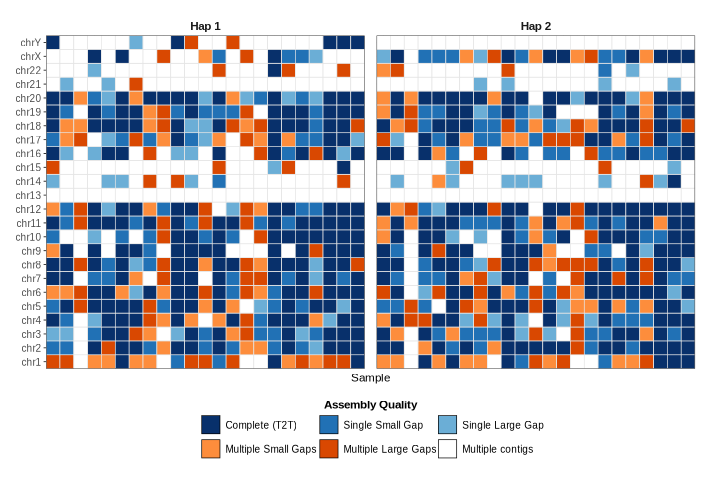

In [140]:
# Define colors for coverage status with clear quality progression
status_colors <- c(
    "Multiple contigs" = "#ffffff",           # White
    "Complete" = "#08306b",            # Dark navy blue (excellent)
    "Single Small Gap" = "#2171b5",    # Medium blue (very good)
    "Single Large Gap" = "#6baed6",    # Light blue (good)
    "Multiple Small Gaps" = "#fd8d3c", # Orange (concerning)
    "Multiple Large Gaps" = "#d94801", # Dark orange/red (problematic)
    "Other" = "#e48bd8"                # Pink (should not appear)
)

# Create the main plot
fig1_A_t2t_grid <- ggplot(plot_data, aes(x = sample, y = chr_factor)) +
    geom_tile(aes(fill = coverage_status), color = "grey90", size = 0.2) +
    scale_fill_manual(
        values = status_colors, 
        name = "Assembly Quality",
        # Order legend by quality (best to worst)
        breaks = c("Complete", "Single Small Gap", "Single Large Gap", 
                  "Multiple Small Gaps", "Multiple Large Gaps", "Multiple contigs", "Other"),
        # Optional: Add more descriptive labels
        labels = c("Complete (T2T)", "Single Small Gap", "Single Large Gap", 
                  "Multiple Small Gaps", "Multiple Large Gaps", "Multiple contigs", "Other")
    ) +
    facet_wrap(~ haplotype, nrow = 1) +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(expand = c(0, 0)) +
    labs(
        x = "Sample",
        y = NULL
    ) +
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = "bottom",
    ) +
    guides(fill = guide_legend(
        title.position = "top",
        title.hjust = 0.5,
        nrow = 2,  # Arrange legend in 2 rows for better space usage
        byrow = TRUE,
        override.aes = list(color = "black", size = 0.5)  # Add borders to legend squares
    ))

ggsave("../../doc/figures/fig1_A_t2t_grid.png", fig1_A_t2t_grid, width = sizes["A1"], height = sizes["A2"])
ggsave("../../doc/figures/fig1_A_t2t_grid.pdf", fig1_A_t2t_grid, width = sizes["A1"], height = sizes["A2"])

options(repr.plot.width = sizes["A1"], repr.plot.height = sizes["A2"])
fig1_A_t2t_grid

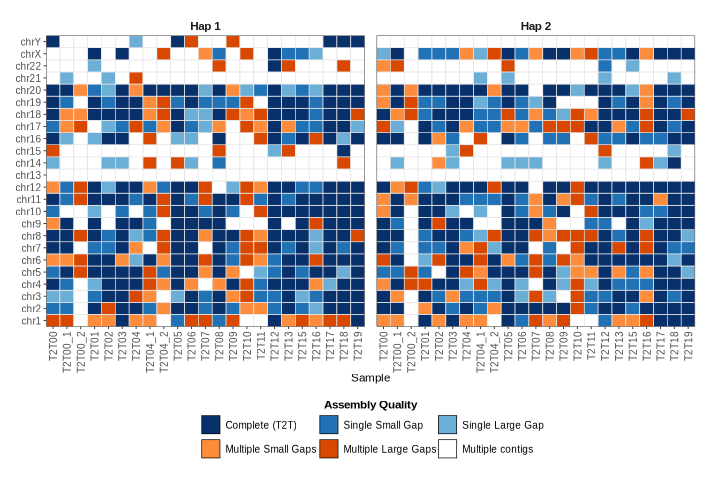

In [141]:
fig1_A_t2t_grid_samplenames <- fig1_A_t2t_grid +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 6),
        axis.ticks.x = element_line()
    )

ggsave("../../doc/figures/fig1_A_t2t_grid_samplenames.png", fig1_A_t2t_grid_samplenames, width = sizes["A1"], height = sizes["A2"])
ggsave("../../doc/figures/fig1_A_t2t_grid_samplenames.pdf", fig1_A_t2t_grid_samplenames, width = sizes["A1"], height = sizes["A2"])

options(repr.plot.width = sizes["A1"], repr.plot.height = sizes["A2"])
fig1_A_t2t_grid_samplenames

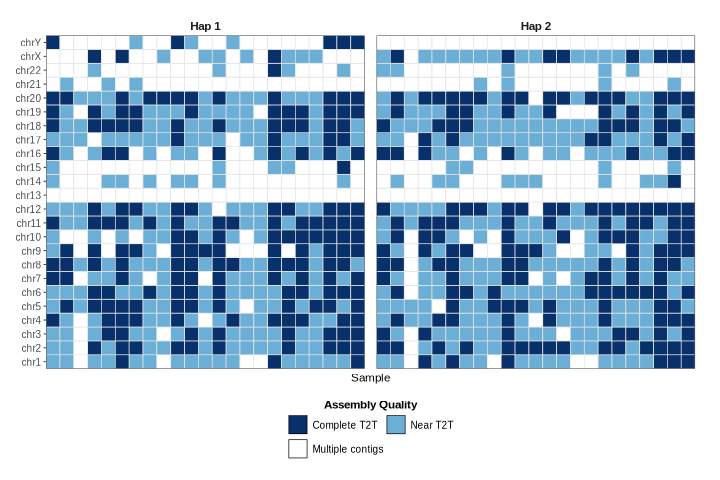

In [148]:
# Define colors for coverage status with clear quality progression
status_colors_simple <- c(
    "Complete T2T" = "#08306b",            # Dark navy blue (excellent)
    "Near T2T" = "#6baed6",    # Light blue (good)
    "Multiple contigs" = "#ffffff"               # White 
)

# Create the main plot
fig1_A_t2t_grid_simple <- ggplot(plot_data, aes(x = sample, y = chr_factor)) +
    geom_tile(aes(fill = coverage_status_simple), color = "grey90", size = 0.2) +
    scale_fill_manual(
        values = status_colors_simple, 
        name = "Assembly Quality",
        # Order legend by quality (best to worst)
        breaks = c("Complete T2T", "Near T2T", "Multiple contigs"),
        # Optional: Add more descriptive labels
        labels = c("Complete T2T", "Near T2T", "Multiple contigs")
    ) +
    facet_wrap(~ haplotype, nrow = 1) +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(expand = c(0, 0)) +
    labs(
        x = "Sample",
        y = NULL
    ) +
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = "bottom",
    ) +
    guides(fill = guide_legend(
        title.position = "top",
        title.hjust = 0.5,
        nrow = 2,  # Arrange legend in 2 rows for better space usage
        byrow = TRUE,
        override.aes = list(color = "black", size = 0.5)  # Add borders to legend squares
    ))

ggsave("../../doc/figures/fig1_A_t2t_grid_simple.png", fig1_A_t2t_grid_simple, width = sizes["A1"], height = sizes["A2"])
ggsave("../../doc/figures/fig1_A_t2t_grid_simple.pdf", fig1_A_t2t_grid_simple, width = sizes["A1"], height = sizes["A2"])

options(repr.plot.width = sizes["A1"], repr.plot.height = sizes["A2"])
fig1_A_t2t_grid_simple

### Figure 2B: QC Beesplot

Plot some of the most important Assembly QC values along with comparison to HPRC samples

In [7]:
hprc <- read_tsv("../../doc/tables/qc_hprc_table.tsv", show_col_types = F ) %>% 
    mutate(source = "hprc")
samples <- read_tsv("../../doc/tables/qc_samples_table.tsv", show_col_types = F) %>%
    mutate(source = "samples")


dt_qc <- bind_rows(hprc, samples) %>%
    filter(haplotype != "both") %>%
    filter(!(metric %in% c("qv")))
head(dt_qc)
tail(dt_qc)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
length,2.947895e+09,haplotype1,phased_hprc,HG002,hprc,NA
ref_covered,9.075000e-01,haplotype1,phased_hprc,HG002,hprc,NA
asm_covered,9.653000e-01,haplotype1,phased_hprc,HG002,hprc,NA
length,3.051530e+09,haplotype2,phased_hprc,HG002,hprc,NA
ref_covered,9.415000e-01,haplotype2,phased_hprc,HG002,hprc,NA
asm_covered,9.686000e-01,haplotype2,phased_hprc,HG002,hprc,NA


metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
MSC,0.05221773,haplotype1,phased_verkko,T2T17,samples,NA
MSC,0.01556011,haplotype2,phased_verkko,T2T17,samples,NA
MSC,0.05290991,haplotype1,phased_verkko,T2T18,samples,NA
MSC,0.01533861,haplotype2,phased_verkko,T2T18,samples,NA
MSC,0.05321446,haplotype1,phased_verkko,T2T19,samples,NA
MSC,0.01619691,haplotype2,phased_verkko,T2T19,samples,NA


In [8]:
metric_labels <- c(
    "length" = "Assembly Length (Mb)",
    "ref_covered" = "Reference Covered (%)",
    "asm_covered" = "Assembly Covered (%)",
    "inter-chromosomal_misjoins" = "Inter-chrom. Misjoins",
    "intra-chromosomal_gaps" = "Intra-chrom. Gaps",
    "candidate_inversions_in_the_middle" = "Inversions (Middle)",
    "candidate_inversions_at_contig_ends" = "Inversions (Ends)",
    "n_T2T" = "n T2T Chrom.",
    "total_n_count" = "Total N Count",
    "total_gaps" = "Total Gaps",
    "n_contigs" = "Number of Contigs",
    "n_contigs_over_10mb" = "n Contigs >10 Mb",
    "genome_completeness" = "Completeness (%)",
    "MMC" = "MMC (%)",
    "MSC" = "MSC (%)"
)

source_labels <- c(
    "hprc" = "HPRC",
    "samples" = "Samples"
)

haplotype_labels <- c(
    "haplotype1" = "Hap 1",
    "haplotype2" = "Hap 2"
)

# Update dt_qc with renamed fields
dt_qc_u <- dt_qc %>%
    mutate(
        metric = recode(metric, !!!metric_labels),
        source = recode(source, !!!source_labels),
        haplotype = recode(haplotype, !!!haplotype_labels)
    )

head(dt_qc)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
length,2.947895e+09,haplotype1,phased_hprc,HG002,hprc,NA
ref_covered,9.075000e-01,haplotype1,phased_hprc,HG002,hprc,NA
asm_covered,9.653000e-01,haplotype1,phased_hprc,HG002,hprc,NA
length,3.051530e+09,haplotype2,phased_hprc,HG002,hprc,NA
ref_covered,9.415000e-01,haplotype2,phased_hprc,HG002,hprc,NA
asm_covered,9.686000e-01,haplotype2,phased_hprc,HG002,hprc,NA


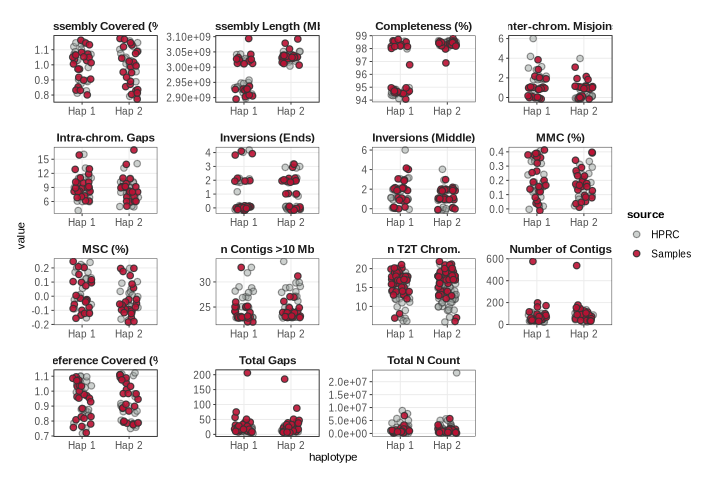

In [9]:
p_qc_beesplot_full <- ggplot(dt_qc_u, aes(x = haplotype, y = value, fill = source, alpha = source)) +
    geom_jitter(width = 0.2, height = 0.2, shape = 21, size = 1.5, colour = "grey20") +
    scale_fill_manual(values = col_source) +
    scale_alpha_manual(values = c("HPRC" = 0.5, "Samples" = 0.9)) +
    facet_wrap(~metric, scales = "free")

ggsave("../../doc/figures/qc_beesplot_full.png", p_qc_beesplot_full, width = 16*0.7, height = 9*0.7)
p_qc_beesplot_full

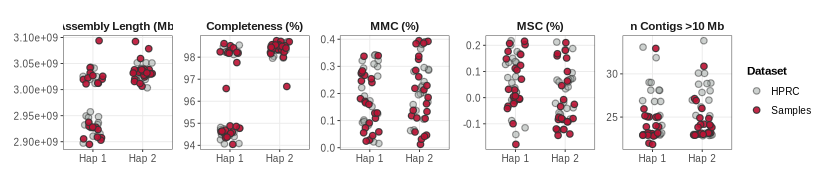

In [10]:
selection <- c(
    "Assembly Length (Mb)",
    "n Contigs >10 Mb",
    "Completeness (%)",
    "MMC (%)",
    "MSC (%)"
    )

p_qc_beesplot <- ggplot(dt_qc_u %>% filter(metric %in% selection), aes(x = haplotype, y = value, fill = source, alpha = source)) +
    geom_jitter(width = 0.2, height = 0.2, shape = 21, size = 1.5, colour = "grey20") +
    scale_fill_manual(values = col_source) +
    scale_alpha_manual(values = c("HPRC" = 0.5, "Samples" = 0.9)) +
    facet_wrap(~metric, scales = "free", nrow = 1) +
    labs(x = NULL, y = NULL, fill = "Dataset", alpha = "Dataset")


ggsave("../../doc/figures/fig1_B_qc_beesplot.png", p_qc_beesplot, width = sizes["B1"] , height = sizes["B2"])
ggsave("../../doc/figures/fig1_B_qc_beesplot.pdf", p_qc_beesplot, width = sizes["B1"] , height = sizes["B2"])

options(repr.plot.width = sizes["B1"], repr.plot.height = sizes["B2"])
p_qc_beesplot

### Figure 1C: ReadQC 

In [11]:
dt_readqc <- read_tsv("../../doc/tables/publication/minknow_metrics_processed_UL.tsv", show_col_types = F)
head(dt_readqc)

flow_cell_id,kit_type,run_start_time,run_end_time,estimated_n50,bases_called_pass,reads_called_pass,elapsed_time_seconds,name_external,run_time_hours
<chr>,<chr>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
PAY80694,SQK-ULK114,2024-12-04 15:15:21,2024-12-11 08:27:32,53714.63,112470746486,4356332,571645,Unknown,158.7903
PBA32113,SQK-ULK114,2024-11-11 13:25:36,2024-11-16 13:31:47,67073.00,106573295444,3832146,432002,Unknown,120.0006
PBA36199,SQK-ULK114,2024-11-11 13:33:02,2024-11-16 13:39:14,77586.00,101170475091,2731211,432002,Unknown,120.0006
PBA75463,SQK-ULK114,2024-12-04 15:15:21,2024-12-11 08:27:32,52435.77,124700727272,4941389,571645,Unknown,158.7903
PBA75681,SQK-ULK114,2024-12-04 15:15:21,2024-12-11 08:27:32,46742.59,92561805832,4558778,571643,Unknown,158.7897
PBA75688,SQK-ULK114,2024-12-04 15:15:21,2024-12-11 08:27:32,28340.84,105671646178,7773711,571645,Unknown,158.7903


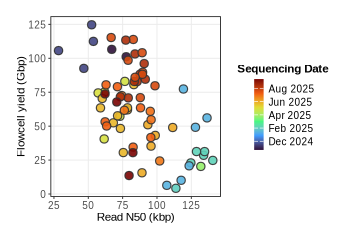

In [12]:
fig1_C_readqc <- ggplot(dt_readqc, aes(x = estimated_n50, y = bases_called_pass, fill = run_end_time)) +
    geom_point(shape = 21, colour = "grey20", alpha = 0.9, size = 2) +
    scale_x_continuous(labels = function(x) x / 1000, name = "Read N50 (kbp)") +
    scale_y_continuous(labels = function(y) y / 1e9, name = "Flowcell yield (Gbp)") +
    scale_fill_viridis_c(
        option = "turbo",
        name = "Sequencing Date",
        breaks = scales::breaks_pretty(n = 5),
        labels = function(x) format(as.Date(as.POSIXct(x, origin = "1970-01-01")), "%b %Y"),
        guide = guide_colorbar(
            title.position = "top",
            title.hjust = 0.5,
            barwidth = unit(0.2, "cm"),
            barheight = unit(1.5, "cm"),
            nbin = 300
        )
    ) 

ggsave("../../doc/figures/fig1_C_readqc.png", fig1_C_readqc, width = sizes["C1"], height = sizes["C2"])
ggsave("../../doc/figures/fig1_C_readqc.pdf", fig1_C_readqc, width = sizes["C1"], height = sizes["C2"])

options(repr.plot.width = sizes["C1"], repr.plot.height = sizes["C2"])
fig1_C_readqc

### D: Ideaogram: Assembly issue chromosome overview

Use Ideogram plot to give a good overview of easy and challenging regions of the geneom.
Should at a first glance show: 
- Where our T2T assemblies were successful
- Where our T2T assemblies failed to generate complete chromosomes
- Regions with potential errors / gaps / misassemblies

Ideogram requires specific data formats:
 1. Karyotype file: chromosome, start, end (and optionally: CE_start, CE_end for centromere)
 2. Data file: chromosome, start, end, value (for overlays)

 Uses [ggideogram](https://github.com/dxsbiocc/ggiodeogram)


Flagger issue types:


|Component|Description|
|:--------|:----------|
|Err  |This block has low read coverage. If located in the middle of a contig it could be a misjoin or a region needing polishing.|
|Dup  |Potential false duplication showing ~half expected coverage / low MAPQ alignments. Likely one copy needs polishing or removal.|
|Hap  |Correctly assembled block with expected read coverage.|
|Col  |Two or more highly similar haplotypes collapsed into one block.|
|MISJOIN|Drop in primary base coverage or a coverage gap; minimal/no reads support this region (may be a scaffold). Can overlap regions with secondary base coverage.|
|COLLAPSE|Sequence collapse with no observed variants (multiple haplotypes merged).|
|COLLAPSE_VAR|Collapse that still shows variants; often overlaps regions with high secondary base coverage.|
|COLLAPSE_OTHER|Regions with atypical signals (e.g., high het ratio) not captured by other collapse categories.|
|HET|Possible heterozygous site determined by het ratio (second-most-common base coverage / (first + second coverage)).

 

In [32]:
library(ggideogram)

In [86]:
# Read cytoband file
cytoband <- read_tsv("../../data/ref/cytoBandMapped.bed",
                     col_names = c("chr", "start", "end", "name", "gieStain", "full_name"),
                     show_col_types = FALSE) %>%
            separate_wider_position(name, 
                widths = c("arm" = 1),
                too_many = "drop",
                cols_remove = FALSE ) 

head (cytoband,3)

# Extract centromeres - they typically have bands named p11.* or q11.* 
# or contain "cen" in the name
centromeres <- cytoband %>%
    filter(str_detect(name, "^p11|^q11|cen")) %>%
    group_by(chr) %>%
    summarise(
        ce_start = min(start),
        ce_end = max(end)
    )

head(centromeres, 3)

chr,start,end,arm,name,gieStain,full_name
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
chr1,0,1735965,p,p36.33,gneg,1p36.33
chr1,1735965,4816989,p,p36.32,gpos25,1p36.32
chr1,4816989,6629068,p,p36.31,gneg,1p36.31


chr,ce_start,ce_end
<chr>,<dbl>,<dbl>
chr1,120413269,126300487
chr10,29331681,51948621
chr11,43555411,54450838


In [122]:
# Create karyotype data from reference FAI file
chm13 <- "../../data/ref/T2T-CHM13.v2.fasta.fai"
karyotype_chm13 <- read_tsv(chm13, 
    col_names = c("chr", "end", "offset", "linebases", "linewidth", "qualoffset"),
    col_types = "cnnnnn",
    show_col_types = FALSE) %>%
    filter(chr != "chrM") %>%
    mutate(start = 1) %>%
    select(chr, start, end) %>%
    # Create numeric sort key BEFORE any factor conversion
    mutate(chr_num = case_when(
        chr == "chrX" ~ 23,
        chr == "chrY" ~ 24,
        TRUE ~ as.numeric(str_remove(chr, "chr"))
    )) %>%
     mutate(
        chr = factor(chr, levels = unique(chr[order(chr_num)])),
    ) %>%
    arrange(chr_num)

# Duplicate haplotypes for diploid plotting
karyotype_chm13_diploid <- karyotype_chm13 %>%
    crossing(haplotype = c("Hap 1", "Hap 2")) %>%
    # Now create ordered factors
    mutate(
        chr = factor(chr, levels = unique(chr[order(chr_num)])),
        haplotype = factor(haplotype, levels = c("Hap 1", "Hap 2"))
    ) %>%
    select(-chr_num) %>%
    arrange(chr, haplotype) %>%
    filter(!(chr=="chrY" & haplotype=="Hap 2")) # Keep chrY only for Hap 1

head(karyotype_chm13, 3)
nrow(karyotype_chm13)

head(karyotype_chm13_diploid, 3)
nrow(karyotype_chm13_diploid)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


chr,start,end,chr_num
<fct>,<dbl>,<dbl>,<dbl>
chr1,1,248387328,1
chr2,1,242696752,2
chr3,1,201105948,3


[1] 24

chr,start,end,haplotype
<fct>,<dbl>,<dbl>,<fct>
chr1,1,248387328,Hap 1
chr1,1,248387328,Hap 2
chr2,1,242696752,Hap 1


[1] 47

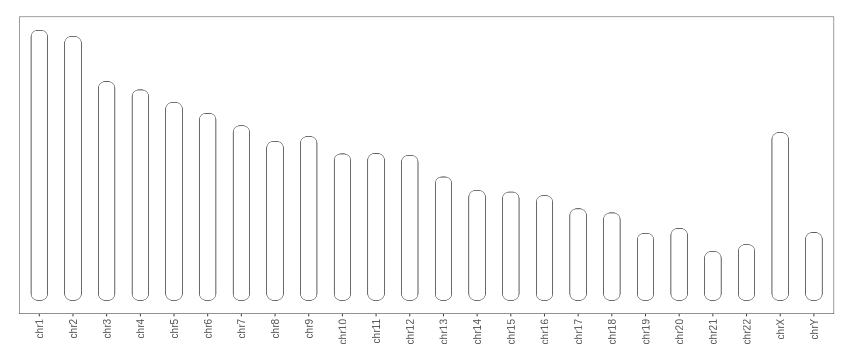

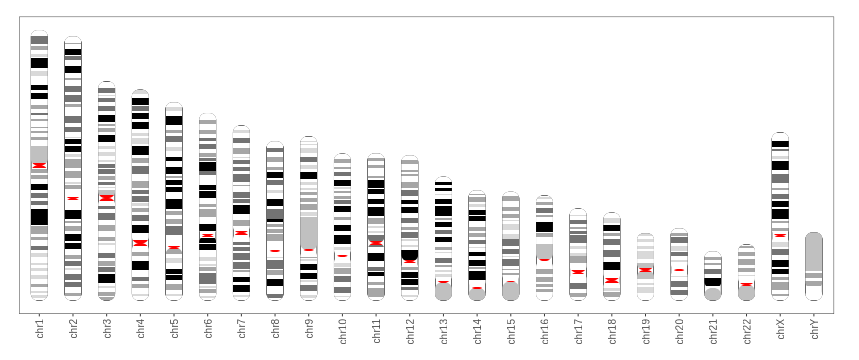

In [110]:
ideogram_haploid_blank <- ggplot(karyotype_chm13) +
    geom_ideogram(aes(
        x = chr,
        ymin = start, ymax = end,
        chrom = chr),
        radius = unit(4, 'pt'), width = 0.5, linewidth = .2,
        colour = 'black', show.legend = F
    ) +
    theme(
        axis.title = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
        panel.grid = element_blank(),
        strip.text = element_text(face = "bold")
    )

ideogram_cytobands <- ideogram_haploid_blank +
    geom_ideogram(data = cytoband,aes(
        x = chr,
        ymin = start, ymax = end,
        chrom = chr, arm = arm,
        fill = gieStain),
        radius = unit(4, 'pt'), width = 0.5, linewidth = .2,
        show.legend = F
    ) + 
    scale_fill_manual(values = cytoband_colors)


options(repr.plot.width = sizes["D1"], repr.plot.height = sizes["D2"])
ideogram_haploid_blank
ideogram_cytobands

In [119]:
dt_issues <- read_tsv("../../doc/tables/for_plots/assembly_issues_all_samples.tsv", show_col_types = F)

dt_issues_plot <- dt_issues %>%
    # Filter for specific feature types of interest (optional)
    filter(feature_type %in% c("Err", "Dup", "Col", "MISJOIN", "COLLAPSE", "COLLAPSE_VAR")) %>%
    # Add arm information by joining with cytoband data
    left_join(
        cytoband %>% 
            select(chr, arm) %>% 
            distinct(), 
        by = "chr",
        relationship = "many-to-many"
    )

head(dt_issues_plot, 3)


sample,source,chr,start,end,length,feature_type,arm
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
T2T00,Flagger,chr1,138553,174566,36013,Dup,p
T2T00,Flagger,chr1,138553,174566,36013,Dup,q
T2T00,Flagger,chr1,795865,847871,52006,Dup,p


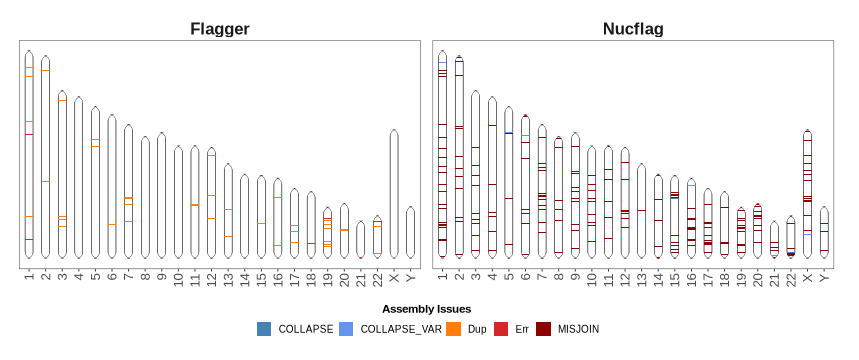

In [125]:
# Define colors for different feature types
feature_colors <- c(
    "Err" = "#d62728",           # Red for errors
    "MISJOIN" = "#8b0000",       # Dark red for misjoins (similar to Err)
    "Col" = "#1f77b4",           # Blue for collapses
    "COLLAPSE" = "#4682b4",      # Steel blue for collapses (similar to Col)
    "COLLAPSE_VAR" = "#6495ed",  # Cornflower blue for variable collapses (similar to Col/COLLAPSE)
    "Dup" = "#ff7f0e"         # Orange for duplications (standalone)
)

# Create the ideogram plot with features
fig1_D_ideogram_with_features <- ideogram_haploid_blank +
    # Add assembly issues as overlays
    geom_ideogram(
        data = dt_issues_ideogram,
        aes(x = chr, ymin = start, ymax = end, chrom = chr, 
            fill = feature_type, arm = arm),
        radius = unit(4, 'pt'), 
        width = 0.5, 
        linewidth = 1.5 ,
        colour = NA,
        alpha = 1
    ) +
    # Facet by source
    facet_wrap(~ source, ncol = 3) +
    # Color scale for features
    scale_fill_manual(
        values = feature_colors,
        name = "Assembly Issues",
        na.value = "transparent"
    ) +
    scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
    theme(
        axis.title = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
        panel.grid = element_blank(),
        strip.text = element_text(face = "bold", size = 10),
        legend.position = "bottom"
    ) +
    guides(fill = guide_legend(
        title.position = "top",
        title.hjust = 0.5,
        nrow = 1
    ))

# Save and display
ggsave(
    plot = fig1_D_ideogram_with_features,
    filename = "../../doc/figures/fig1_D_ideogram_with_features.png",
    width = sizes["D1"], height = sizes["D2"], units = "in", dpi = 300
)

ggsave(
    plot = fig1_D_ideogram_with_features,
    filename = "../../doc/figures/fig1_D_ideogram_with_features.pdf",
    width = sizes["D1"], height = sizes["D2"], units = "in", dpi = 300
)

options(repr.plot.width = sizes["D1"], repr.plot.height = 3)

fig1_D_ideogram_with_features

In [126]:
# Method 1: Binning approach for density calculation
calculate_feature_density_binned <- function(data, bin_size = 1e6) {
    # Create chromosome-wide bins
    data %>%
        # Filter for main chromosomes only
        filter(str_detect(chr, "^chr[0-9XY]+$")) %>%
        mutate(
            # Create bins based on genomic position
            bin = floor(start / bin_size) * bin_size,
            bin_end = bin + bin_size,
            chr_num = case_when(
                chr == "chrX" ~ 23,
                chr == "chrY" ~ 24,
                TRUE ~ as.numeric(str_remove(chr, "chr"))
            )
        ) %>%
        # Count features per bin
        group_by(source, chr, chr_num, bin, bin_end, feature_type) %>%
        summarise(
            feature_count = n(),
            total_length = sum(length),
            .groups = "drop"
        ) %>%
        # Calculate density as features per Mb
        mutate(
            density = feature_count / (bin_size / 1e6),
            length_density = total_length / (bin_size / 1e6)
        ) %>%
        arrange(chr_num, bin)
}

# Method 2: Kernel density estimation approach
calculate_feature_density_kde <- function(data, bandwidth = 5e6) {
    # Get chromosome lengths from karyotype data
    chr_lengths <- karyotype_chm13 %>%
        select(chr, end) %>%
        distinct() %>%
        mutate(chr_num = case_when(
            chr == "chrX" ~ 23,
            chr == "chrY" ~ 24,
            TRUE ~ as.numeric(str_remove(chr, "chr"))
        ))
    
    # Calculate KDE for each chromosome and source
    density_data <- data %>%
        filter(str_detect(chr, "^chr[0-9XY]+$")) %>%
        filter(feature_type %in% c("Err", "Dup", "MISJOIN", "COLLAPSE", "COLLAPSE_VAR")) %>%
        group_by(source, chr, feature_type) %>%
        group_split() %>%
        map_dfr(function(group_data) {
            if(nrow(group_data) < 3) return(tibble()) # Skip if too few points
            
            chr_info <- chr_lengths %>% filter(chr == unique(group_data$chr))
            if(nrow(chr_info) == 0) return(tibble())
            
            # Use midpoint of features for density calculation
            positions <- (group_data$start + group_data$end) / 2
            
            # Create density estimation
            dens <- density(positions, 
                          bw = bandwidth,
                          from = 1, 
                          to = chr_info$end,
                          n = 512)
            
            tibble(
                source = unique(group_data$source),
                chr = unique(group_data$chr),
                feature_type = unique(group_data$feature_type),
                position = dens$x,
                density = dens$y * length(positions) # Scale by number of features
            )
        })
    
    return(density_data)
}

# Calculate densities using both methods
density_binned <- calculate_feature_density_binned(dt_issues_plot, bin_size = 2e6) # 2Mb bins
density_kde <- calculate_feature_density_kde(dt_issues_plot, bandwidth = 5e6) # 5Mb bandwidth

head(density_binned)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


source,chr,chr_num,bin,bin_end,feature_type,feature_count,total_length,density,length_density
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Flagger,chr1,1,0e+00,2e+06,Dup,6,344044,3,172022
Nucflag,chr1,1,0e+00,2e+06,COLLAPSE_VAR,4,78816,2,39408
Nucflag,chr1,1,0e+00,2e+06,MISJOIN,54,2036538,27,1018269
Flagger,chr1,1,2e+06,4e+06,Err,2,36416,1,18208
Nucflag,chr1,1,2e+06,4e+06,MISJOIN,40,1002064,20,501032
Nucflag,chr1,1,4e+06,6e+06,MISJOIN,2,91538,1,45769


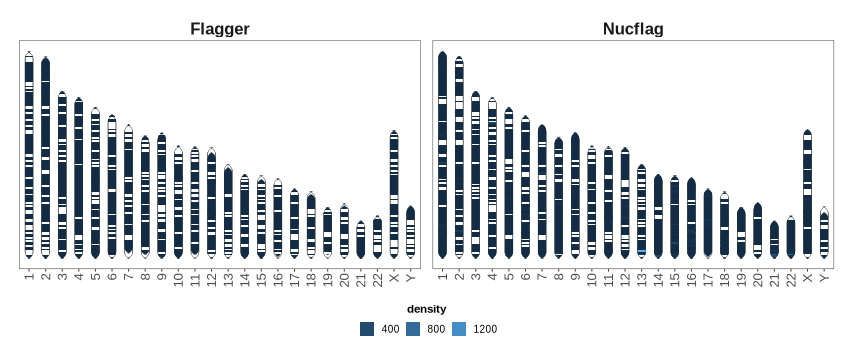

In [129]:
# Create the ideogram plot with features
fig1_D_ideogram_density <- ideogram_haploid_blank +
    # Add assembly issues as overlays
    geom_ideogram(
        data = density_binned,
        aes(x = chr, ymin = bin, ymax = bin_end, chrom = chr, 
            fill = density),
        radius = unit(4, 'pt'), 
        width = 0.5, 
        linewidth = 1.5 ,
        colour = NA,
        alpha = 1
    ) +
    # Facet by source
    facet_wrap(~ source, ncol = 3) +
    # Color scale for features
    scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
    theme(
        axis.title = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
        panel.grid = element_blank(),
        strip.text = element_text(face = "bold", size = 10),
        legend.position = "bottom"
    ) +
    guides(fill = guide_legend(
        title.position = "top",
        title.hjust = 0.5,
        nrow = 1
    ))

# Save and display
ggsave(
    plot = fig1_D_ideogram_density,
    filename = "../../doc/figures/fig1_D_ideogram_density.png",
    width = sizes["D1"], height = sizes["D2"], units = "in", dpi = 300
)

ggsave(
    plot = fig1_D_ideogram_density,
    filename = "../../doc/figures/fig1_D_ideogram_density.pdf",
    width = sizes["D1"], height = sizes["D2"], units = "in", dpi = 300
)

options(repr.plot.width = sizes["D1"], repr.plot.height = 3)

fig1_D_ideogram_density


In [ ]:

# Plot 1: Binned density heatmap
plot_density_binned <- density_binned %>%
    filter(feature_type %in% c("Err", "Dup", "MISJOIN", "COLLAPSE", "COLLAPSE_VAR")) %>%
    mutate(
        chr = factor(chr, levels = levels(karyotype_chm13$chr)),
        # Cap density for better visualization
        density_capped = pmin(density, quantile(density, 0.95, na.rm = TRUE))
    ) %>%
    ggplot(aes(x = bin/1e6, y = chr, fill = density_capped)) +
    geom_tile() +
    facet_grid(feature_type ~ source, scales = "free_y") +
    scale_fill_viridis_c(name = "Features\nper Mb", option = "plasma") +
    scale_x_continuous(name = "Genomic Position (Mb)") +
    scale_y_discrete(name = "Chromosome") +
    theme_minimal() +
    theme(
        axis.text.y = element_text(size = 8),
        strip.text = element_text(size = 8),
        legend.position = "right"
    )
plot_density_binned
ggsave("../../doc/figures/feature_density_binned.png", plot_density_binned, 
       width = 14, height = 20, dpi = 300)

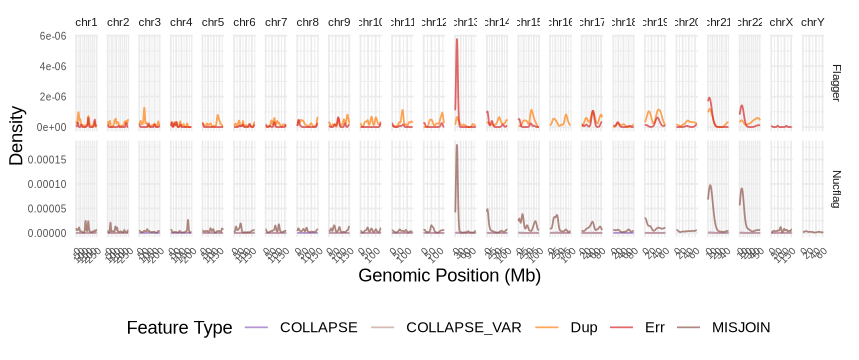

In [69]:

# Plot 2: KDE density curves
plot_density_kde <- density_kde %>%
    mutate(chr = factor(chr, levels = levels(karyotype_chm13$chr))) %>%
    ggplot(aes(x = position/1e6, y = density, color = feature_type)) +
    geom_line(alpha = 0.7, size = 0.5) +
    facet_grid(source ~ chr, scales = "free") +
    scale_color_manual(values = feature_colors, name = "Feature Type") +
    scale_x_continuous(name = "Genomic Position (Mb)") +
    scale_y_continuous(name = "Density") +
    theme_minimal() +
    theme(
        axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
        axis.text.y = element_text(size = 6),
        strip.text = element_text(size = 7),
        legend.position = "bottom"
    )
plot_density_kde
ggsave("../../doc/figures/feature_density_kde.png", plot_density_kde, 
       width = 16, height = 8, dpi = 300)

In [ ]:

# Plot 3: Summary density by chromosome
density_summary <- dt_issues_clean %>%
    filter(feature_type %in% c("Err", "Dup", "MISJOIN", "COLLAPSE", "COLLAPSE_VAR")) %>%
    left_join(karyotype_chm13 %>% select(chr, end) %>% distinct(), by = "chr") %>%
    group_by(source, chr, feature_type, end) %>%
    summarise(
        feature_count = n(),
        total_length = sum(length),
        .groups = "drop"
    ) %>%
    mutate(
        density_per_mb = (feature_count / end) * 1e6,
        length_density_per_mb = (total_length / end) * 1e6,
        chr_num = case_when(
            chr == "chrX" ~ 23,
            chr == "chrY" ~ 24,
            TRUE ~ as.numeric(str_remove(chr, "chr"))
        )
    ) %>%
    arrange(chr_num)

plot_density_summary <- density_summary %>%
    ggplot(aes(x = reorder(chr, chr_num), y = density_per_mb, fill = feature_type)) +
    geom_col(position = "stack") +
    facet_wrap(~ source, ncol = 1) +
    scale_fill_manual(values = feature_colors, name = "Feature Type") +
    scale_x_discrete(name = "Chromosome") +
    scale_y_continuous(name = "Features per Mb") +
    theme_minimal() +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom"
    )

# Save plots


ggsave("../../doc/figures/feature_density_summary.png", plot_density_summary, 
       width = 12, height = 6, dpi = 300)

# Display plots
plot_density_binned

plot_density_summary

### Figure 1: Composition

Allowed figure sizes (Nature):

- 89mm single col
- 183mm double col
- 120mm where necessary with legend at the side

Resolution: 300dpi
Vector output
Embed fonts with true type2 or 42